In [ ]:
dat <- data.frame(
  study = c("I", "II", "III", "IV", "V"),
  a = c(63, 35, 300, 250, 4),
  n_t = c(100, 40, 500, 1000, 10),
  c = c(20, 10, 100, 300, 3),
  n_c = c(100, 20, 300, 1000, 10)
)

dat$b <- dat$n_t - dat$a
dat$d <- dat$n_c - dat$c

In [ ]:
# install.packages("metafor")
library(metafor)

# Данные
dat <- data.frame(
  study = c("I", "II", "III", "IV", "V"),
  ai = c(63, 35, 300, 250, 4),      # успехи в опытной группе
  n1i = c(100, 40, 500, 1000, 10),
  ci = c(20, 10, 100, 300, 3),      # успехи в контрольной группе
  n2i = c(100, 20, 300, 1000, 10)
)

# Неуспехи
dat$bi <- dat$n1i - dat$ai
dat$di <- dat$n2i - dat$ci

# Размер холста для Jupyter
options(repr.plot.width = 8, repr.plot.height = 6)

# Effect sizes: log(OR) + variance
es <- escalc(
  measure = "OR",
  ai = ai, bi = bi, ci = ci, di = di,
  data = dat
)

# Random-effects model
res <- rma(yi, vi, data = es, method = "REML")

# Forest plot
par(mar = c(4, 4, 2, 2))

forest(
  res,
  slab = dat$study,
  atransf = exp,
  refline = 1,
  xlab = "Odds Ratio",
  mlab = "Overall",
  cex = 1.1,
  psize = 1.4,
  at = log(c(0.25, 0.5, 1, 2, 4, 8, 16))
)

In [ ]:
library(metafor)

dat <- data.frame(
  study = c("I", "II", "III", "IV", "V"),
  ai = c(63, 35, 300, 250, 4),
  n1i = c(100, 40, 500, 1000, 10),
  ci = c(20, 10, 100, 300, 3),
  n2i = c(100, 20, 300, 1000, 10)
)

dat$bi <- dat$n1i - dat$ai
dat$di <- dat$n2i - dat$ci

options(repr.plot.width = 8, repr.plot.height = 6)

es <- escalc(
  measure = "OR",
  ai = ai, bi = bi, ci = ci, di = di,
  data = dat
)

res <- rma(yi, vi, data = es, method = "REML")

par(mar = c(4, 4, 2, 2))

forest(
  res,
  slab = dat$study,
  atransf = exp,
  refline = 1,              # 🔥 линия отсутствия эффекта
  addfit = TRUE,           # ромб
  cex = 1.1,
  psize = 1.4,
  at = log(c(0.25, 0.5, 1, 2, 4, 8, 16))
)

# 🔥 добавляем линию общего эффекта (пунктир)
abline(v = coef(res), lty = 2)

In [ ]:
library(metafor)

dat <- data.frame(
  study = c("I", "II", "III", "IV", "V"),
  ai = c(63, 35, 300, 250, 4),
  n1i = c(100, 40, 500, 1000, 10),
  ci = c(20, 10, 100, 300, 3),
  n2i = c(100, 20, 300, 1000, 10)
)

dat$bi <- dat$n1i - dat$ai
dat$di <- dat$n2i - dat$ci

options(repr.plot.width = 8, repr.plot.height = 6)

es <- escalc(
  measure = "OR",
  ai = ai, bi = bi, ci = ci, di = di,
  data = dat
)

res <- rma(yi, vi, data = es, method = "REML")

par(mar = c(4, 4, 2, 2))

jpeg("forest.jpg")

forest(
  res,
  slab = dat$study,
  atransf = exp,
  refline = 0,   # <- линия отсутствия эффекта: log(OR)=0, то есть OR=1
  addfit = TRUE,
  cex = 1.1,
  psize = 1.4,
  at = log(c(0.25, 0.5, 1, 2, 4, 8, 16)),
  xlab = "Odds Ratio"
)



In [ ]:
library(metafor)

# -----------------------------
# Данные
# -----------------------------
dat <- data.frame(
  study = c("I", "II", "III", "IV", "V"),
  ai = c(63, 35, 300, 250, 4),      # успехи в опытной группе
  n1i = c(100, 40, 500, 1000, 10),
  ci = c(20, 10, 100, 300, 3),      # успехи в контрольной группе
  n2i = c(100, 20, 300, 1000, 10)
)

dat$bi <- dat$n1i - dat$ai
dat$di <- dat$n2i - dat$ci

# -----------------------------
# Effect sizes
# -----------------------------
es <- escalc(
  measure = "OR",
  ai = ai, bi = bi, ci = ci, di = di,
  data = dat
)

# Random-effects model
res <- rma(yi, vi, data = es, method = "REML")

# Веса random-effects
w <- weights(res)
w_pct <- round(100 * w / sum(w), 1)

# Текст справа: OR [95% CI]
or_vals <- exp(es$yi)
ci_lb <- exp(es$yi - 1.96 * sqrt(es$vi))
ci_ub <- exp(es$yi + 1.96 * sqrt(es$vi))

or_ci_text <- paste0(
  sprintf("%.2f", or_vals),
  " [", sprintf("%.2f", ci_lb),
  "; ", sprintf("%.2f", ci_ub), "]"
)

# Размер холста для Jupyter
options(repr.plot.width = 10, repr.plot.height = 7)

# -----------------------------
# Forest plot
# -----------------------------
par(mar = c(5, 4, 4, 2))

forest(
  res,
  slab = dat$study,
  atransf = exp,
  refline = 0,   # OR = 1 в лог-шкале
  xlab = "Odds Ratio",
  mlab = "Overall (random-effects)",
  at = log(c(0.25, 0.5, 1, 2, 4, 8, 16)),
  ilab = cbind(or_ci_text, paste0(w_pct, "%")),
  ilab.xpos = c(-2.5, -0.9),
  cex = 1.0,
  psize = 1.3
)

# Линия общего эффекта
abline(v = coef(res), lty = 2)

# Заголовки дополнительных колонок
text(-2.5, 7, "OR [95% CI]", font = 2, cex = 0.9)
text(-0.9, 7, "Weight", font = 2, cex = 0.9)

# Подпись сверху
title("Forest plot for 5 toy studies")

# Блок с гетерогенностью под графиком
het_text <- paste0(
  "Model: random-effects (REML)   ",
  "Q = ", sprintf("%.2f", res$QE),
  ", df = ", res$k - 1,
  ", p = ", ifelse(res$QEp < 0.001, "<0.001", sprintf("%.3f", res$QEp)),
  ", I^2 = ", sprintf("%.1f", res$I2), "%",
  ", tau^2 = ", sprintf("%.3f", res$tau2)
)

mtext(het_text, side = 1, line = 3, cex = 0.9)


=== meta ===
Random-effects OR = 2.761 
95% CI            = [ 1.019 ; 7.483 ]
Q = 88.632 
p(Q) = 2.57e-18 
I^2 = 1 %
tau^2 = 1.071 

=== metafor ===
Random-effects OR = 2.741 
95% CI            = [ 1.112 ; 6.758 ]
Q = 88.632 
p(Q) = 2.57e-18 
I^2 = 94.4 %
tau^2 = 0.849 


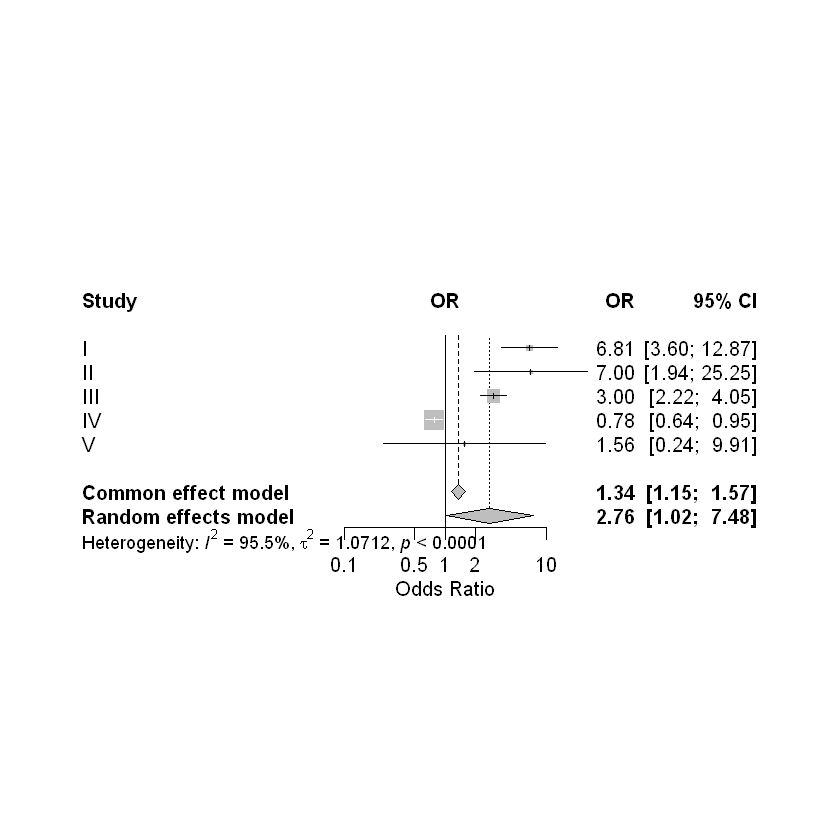

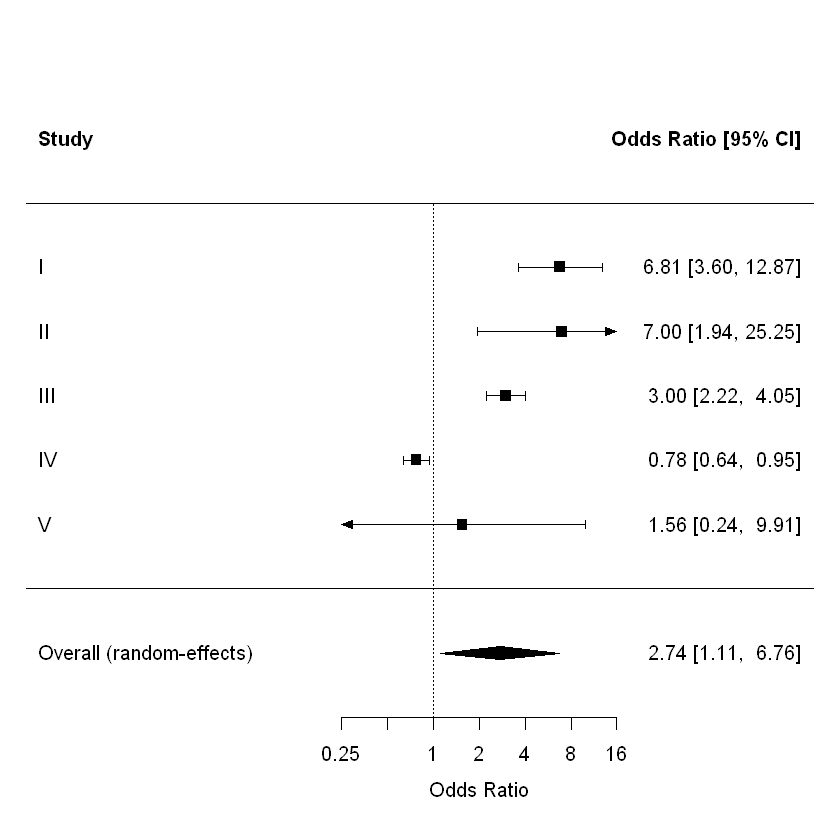

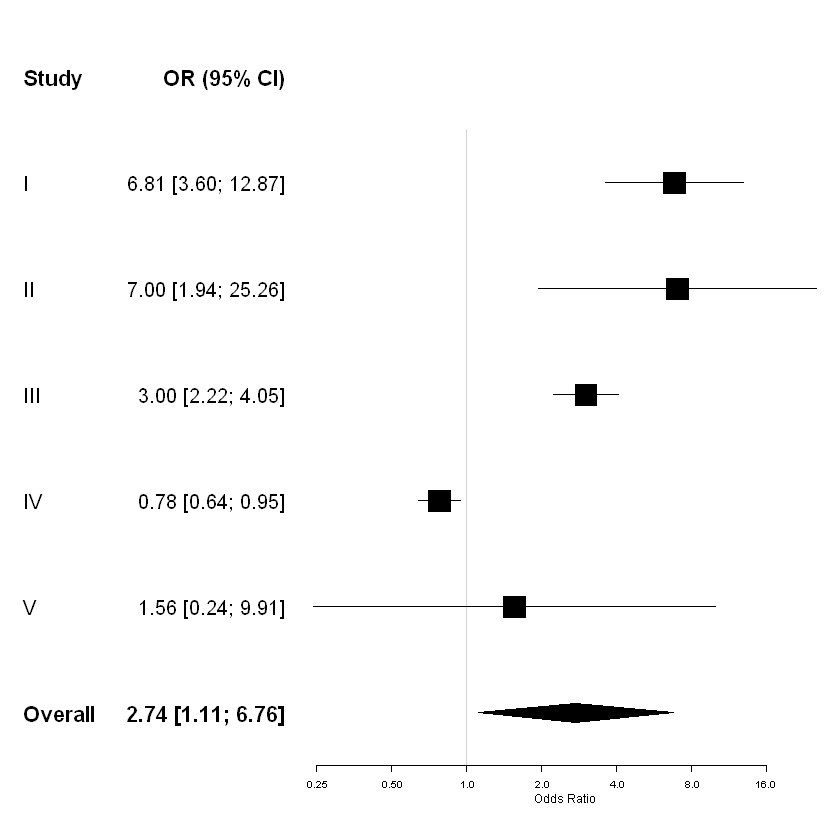

In [2]:
# install.packages(c("meta", "metafor", "forestplot"))

############################################################
# 1. Данные
############################################################

dat <- data.frame(
  study = c("I", "II", "III", "IV", "V"),
  a = c(63, 35, 300, 250, 4),      # успехи в опытной группе
  n_t = c(100, 40, 500, 1000, 10),
  c = c(20, 10, 100, 300, 3),      # успехи в контрольной группе
  n_c = c(100, 20, 300, 1000, 10),
  stringsAsFactors = FALSE
)

dat$b <- dat$n_t - dat$a
dat$d <- dat$n_c - dat$c

############################################################
# 2. meta
############################################################

library(meta)

m <- metabin(
  event.e = a,
  n.e     = n_t,
  event.c = c,
  n.c     = n_c,
  studlab = study,
  data    = dat,
  sm      = "OR",
  method  = "Inverse",
  method.tau = "DL",
  common  = TRUE,
  random  = TRUE
)

############################################################
# 3. metafor
############################################################

library(metafor)

es <- escalc(
  measure = "OR",
  ai = a, bi = b, ci = c, di = d,
  data = dat
)

res_RE <- rma(yi, vi, data = es, method = "REML")
res_FE <- rma(yi, vi, data = es, method = "FE")

############################################################
# 4. forestplot (только рисует)
############################################################

library(forestplot)

dat$OR <- (dat$a * dat$d) / (dat$b * dat$c)
dat$logOR <- log(dat$OR)
dat$SE <- sqrt(1/dat$a + 1/dat$b + 1/dat$c + 1/dat$d)
dat$lower <- exp(dat$logOR - 1.96 * dat$SE)
dat$upper <- exp(dat$logOR + 1.96 * dat$SE)

############################################################
# 5. Короткая сводка
############################################################

cat("\n=== meta ===\n")
cat("Random-effects OR =", round(exp(m$TE.random), 3), "\n")
cat("95% CI            = [", round(exp(m$lower.random), 3), ";", round(exp(m$upper.random), 3), "]\n")
cat("Q =", round(m$Q, 3), "\n")
cat("p(Q) =", signif(m$pval.Q, 3), "\n")
cat("I^2 =", round(m$I2, 1), "%\n")
cat("tau^2 =", round(m$tau2, 3), "\n")

cat("\n=== metafor ===\n")
cat("Random-effects OR =", round(exp(res_RE$b[1,1]), 3), "\n")
cat("95% CI            = [", round(exp(res_RE$ci.lb), 3), ";", round(exp(res_RE$ci.ub), 3), "]\n")
cat("Q =", round(res_RE$QE, 3), "\n")
cat("p(Q) =", signif(res_RE$QEp, 3), "\n")
cat("I^2 =", round(res_RE$I2, 1), "%\n")
cat("tau^2 =", round(res_RE$tau2, 3), "\n")

############################################################
# 6. Forest plot через meta
############################################################

# Для Jupyter можно раскомментировать:
# options(repr.plot.width = 8, repr.plot.height = 6)

forest(
  m,
  comb.fixed = FALSE,
  comb.random = TRUE,
  leftcols = "studlab",
  rightcols = c("effect", "ci"),
  rightlabs = c("OR", "95% CI"),
  xlab = "Odds Ratio",
  smlab = "OR"
)

############################################################
# 7. Forest plot через metafor
############################################################

forest(
  res_RE,
  slab = dat$study,
  atransf = exp,
  refline = 0,  # log(OR)=0 <=> OR=1
  xlab = "Odds Ratio",
  mlab = "Overall (random-effects)",
  cex = 1.0,
  psize = 1.2,
  at = log(c(0.25, 0.5, 1, 2, 4, 8, 16))
)

############################################################
# 8. Forest plot через forestplot
############################################################

mean_vals  <- c(NA, dat$OR, exp(res_RE$b[1,1]))
lower_vals <- c(NA, dat$lower, exp(res_RE$ci.lb))
upper_vals <- c(NA, dat$upper, exp(res_RE$ci.ub))

labeltext <- cbind(
  c("Study", dat$study, "Overall"),
  c(
    "OR (95% CI)",
    paste0(
      sprintf("%.2f", dat$OR),
      " [", sprintf("%.2f", dat$lower),
      "; ", sprintf("%.2f", dat$upper), "]"
    ),
    paste0(
      sprintf("%.2f", exp(res_RE$b[1,1])),
      " [", sprintf("%.2f", exp(res_RE$ci.lb)),
      "; ", sprintf("%.2f", exp(res_RE$ci.ub)), "]"
    )
  )
)

forestplot(
  labeltext = labeltext,
  mean  = mean_vals,
  lower = lower_vals,
  upper = upper_vals,
  is.summary = c(TRUE, rep(FALSE, nrow(dat)), TRUE),
  zero = 1,
  xlog = TRUE,
  boxsize = 0.2,
  col = fpColors(box = "black", line = "black", summary = "black"),
  xlab = "Odds Ratio"
)